# Attribution Analysis for Mutual Fund Comparison (Interpreto)

This notebook applies three attribution methods from the **Interpreto** library to understand which input features drive the Llama-3.2-3B-Instruct model's decisions when comparing mutual fund pairs.

**Google Colab:** Run cells top to bottom. The notebook clones [alanmohan/RA-Mutual-Fund-Task](https://github.com/alanmohan/RA-Mutual-Fund-Task) into `/content/RA-Mutual-Fund-Task` so paths match the GitHub repo layout (`input_csvs/`, `prompts/`, `llm_eval_mutual_funds/`). Enable a **GPU** runtime (**Runtime → Change runtime type → GPU**) before loading the model.

**Methods:**
1. **Integrated Gradients** — gradient-based, integrates gradients along an interpolation path ([Interpreto docs](https://for-sight-ai.github.io/interpreto/api/attributions/methods/integrated_gradients/))
2. **KernelSHAP** — inference-based Shapley-style attributions ([KernelSHAP](https://for-sight-ai.github.io/interpreto/api/attributions/methods/kernelshap/))
3. **Occlusion** — perturbation-based importance ([Occlusion](https://for-sight-ai.github.io/interpreto/api/attributions/methods/occlusion/))

**Task:** Given a pair of mutual funds with structured financial features, the model is prompted to decide which fund to invest in (zero-shot prompt, Llama-3.2-3B-Instruct).

**Goal:** Identify which financial features (expense ratio, Sharpe ratio, beta, etc.) are most important to the model's prediction.

## 0. Setup & installation (Colab-compatible)

1. **Install packages** (cell below) — uses `%pip` so the Colab kernel picks up new packages.
2. **Clone the repository** — fetches `input_csvs/`, `prompts/`, and `llm_eval_mutual_funds/` from GitHub.
3. **Hugging Face:** `meta-llama/Llama-3.2-3B-Instruct` is gated. In Colab, open **Secrets** (or set env var) and add `HF_TOKEN`, or run `huggingface-cli login` once. See [HF docs](https://huggingface.co/docs/hub/security-tokens).

In [1]:
# Colab: %pip installs into the active kernel (recommended over !pip)
import os
# Reduces CUDA fragmentation OOM during attribution (many backward passes)
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

%pip install -q --upgrade pip
%pip install -q interpreto transformers accelerate safetensors huggingface_hub
%pip install -q pandas numpy scipy matplotlib tqdm

# PyTorch: Colab images ship with CUDA-enabled torch; local installs may need:
#   pip install torch --index-url https://download.pytorch.org/whl/cu124
import torch
print("torch:", torch.__version__, "| cuda:", torch.cuda.is_available())


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 35.4 MB/s eta 0:00:00
torch: 2.10.0+cu128 | cuda: True


In [2]:
"""Clone RA-Mutual-Fund-Task and set paths to match the GitHub repo layout."""
import os
import subprocess
from pathlib import Path
from typing import Optional

REPO_URL = "https://github.com/alanmohan/RA-Mutual-Fund-Task.git"
CLONE_PARENT = Path("/content")  # Colab default working area
REPO_DIR_NAME = "RA-Mutual-Fund-Task"


def _is_colab() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


def _find_repo_root_local() -> Optional[Path]:
    """Walk up from cwd to find a directory containing input_csvs/mutual_funds_pairs_no_date.csv."""
    p = Path.cwd().resolve()
    for _ in range(8):
        marker = p / "input_csvs" / "mutual_funds_pairs_no_date.csv"
        if marker.is_file():
            return p
        if p.parent == p:
            break
        p = p.parent
    return None


IN_COLAB = _is_colab()

if IN_COLAB:
    REPO_ROOT = (CLONE_PARENT / REPO_DIR_NAME).resolve()
    marker = REPO_ROOT / "input_csvs" / "mutual_funds_pairs_no_date.csv"
    if not marker.is_file():
        if not REPO_ROOT.is_dir():
            print(f"Cloning {REPO_URL} into {CLONE_PARENT} ...")
            subprocess.run(
                ["git", "clone", REPO_URL],
                cwd=str(CLONE_PARENT),
                check=True,
            )
        else:
            print(f"Updating existing repo at {REPO_ROOT} ...")
            subprocess.run(
                ["git", "pull", "--ff-only"],
                cwd=str(REPO_ROOT),
                check=False,
            )
    assert marker.is_file(), (
        "Clone failed or repo layout changed; expected input_csvs/mutual_funds_pairs_no_date.csv"
    )
else:
    found = _find_repo_root_local()
    if found is not None:
        REPO_ROOT = found
    else:
        # Fallback: assume notebook lives at llm_eval_mutual_funds/interpreto_attributions/
        REPO_ROOT = Path.cwd().resolve().parent.parent
        if not (REPO_ROOT / "input_csvs" / "mutual_funds_pairs_no_date.csv").is_file():
            raise FileNotFoundError(
                "Could not find repo root. Open this notebook from the cloned RA-Mutual-Fund-Task repo, "
                "or run on Colab so the clone step can create /content/RA-Mutual-Fund-Task."
            )

PROJECT_ROOT = REPO_ROOT / "llm_eval_mutual_funds"
NOTEBOOK_DIR = PROJECT_ROOT / "interpreto_attributions"

DATA_PATH = REPO_ROOT / "input_csvs" / "mutual_funds_pairs_no_date.csv"
PROMPT_TEMPLATE_PATH = REPO_ROOT / "prompts" / "zero_shot_prompt_template.txt"
SYSTEM_PROMPT_PATH = REPO_ROOT / "prompts" / "system_prompt.txt"
OUTPUT_DIR = NOTEBOOK_DIR / "results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Optional: Colab Secret "HF_TOKEN" for gated models (e.g. Llama on Hugging Face)
if IN_COLAB:
    try:
        from google.colab import userdata  # type: ignore

        _hf = userdata.get("HF_TOKEN", None)
        if _hf:
            os.environ["HF_TOKEN"] = _hf
            os.environ["HUGGINGFACE_HUB_TOKEN"] = _hf
            print("Loaded HF_TOKEN from Colab Secrets.")
    except Exception:
        pass

print(f"IN_COLAB={IN_COLAB}")
print(f"REPO_ROOT={REPO_ROOT}")
print(f"DATA_PATH exists: {DATA_PATH.is_file()}")
print(f"OUTPUT_DIR={OUTPUT_DIR}")


Cloning https://github.com/alanmohan/RA-Mutual-Fund-Task.git into /content ...
IN_COLAB=True
REPO_ROOT=/content/RA-Mutual-Fund-Task
DATA_PATH exists: True
OUTPUT_DIR=/content/RA-Mutual-Fund-Task/llm_eval_mutual_funds/interpreto_attributions/results


In [3]:
import sys, os
import gc
import re
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import torch
from pathlib import Path
from transformers import AutoModelForCausalLM, AutoTokenizer

from interpreto import (
    Granularity,
    IntegratedGradients,
    KernelShap,
    Occlusion,
    plot_attributions,
)
from interpreto.attributions import InferenceModes
from interpreto.commons import GranularityAggregationStrategy

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    print("Using Apple MPS backend")


PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


## 1. Configuration

In [4]:
# Paths DATA_PATH, PROMPT_TEMPLATE_PATH, SYSTEM_PROMPT_PATH, OUTPUT_DIR, NOTEBOOK_DIR, PROJECT_ROOT, REPO_ROOT
# are set in the clone / repo-root cell (section 0).

# Model — optional local weights under llm_eval_mutual_funds/models/; else Hugging Face Hub
MODEL_NAME = "meta-llama/Llama-3.2-3B-Instruct"
LOCAL_MODEL_PATH = PROJECT_ROOT / "models" / "Llama-3.2-3B-Instruct"

# Experiment settings
N_SAMPLES = 200        # max fund pairs to analyze (capped to available non-tie rows; attribution is slow at scale)
RANDOM_STATE = 42
BATCH_SIZE = 1         # interpreto batch size (1 is safest for memory)

# --- VRAM tuning (generation + attribution can be very memory-heavy) ---
# Long CoT + many IG steps can exceed 40GB; you do NOT need a bigger GPU if you shorten targets & steps.
GEN_MAX_NEW_TOKENS = 128       # max tokens when generating the model reply (for display / logging)
ATTRIB_TARGET_MODE = "minimal"  # "minimal" = only final "mutual fund 1|2" for attribution; "full" = entire reply (huge VRAM)
IG_N_PERTURBATIONS = 10        # IG integration steps; try 6–12 on ~40GB, increase if you have headroom
SHAP_N_PERTURBATIONS = 64      # KernelSHAP forward passes; lower if SHAP OOMs
USE_GRADIENT_CHECKPOINTING = True  # trades speed for much lower peak VRAM during IG backward

# Occlusion-specific: SENTENCE granularity drastically reduces perturbation count
# (~25 sentences vs ~400 words), keeping the full prompt intact so feature aggregation works.
OCC_MAX_SAMPLES = 200
OCC_USE_SINGLE_TOKEN_TARGET = True  # use "1"/"2" as target to minimize generated-token dimension
print(f"Data path: {DATA_PATH}")
print(f"Prompt template: {PROMPT_TEMPLATE_PATH}")
print(f"Output dir: {OUTPUT_DIR}")


Data path: /content/RA-Mutual-Fund-Task/input_csvs/mutual_funds_pairs_no_date.csv
Prompt template: /content/RA-Mutual-Fund-Task/prompts/zero_shot_prompt_template.txt
Output dir: /content/RA-Mutual-Fund-Task/llm_eval_mutual_funds/interpreto_attributions/results


## 2. Load Data & Build Prompts

In [5]:
df = pd.read_csv(DATA_PATH)
print(f"Total pairs: {len(df)}")

# Load prompt templates
ZERO_SHOT_TEMPLATE = PROMPT_TEMPLATE_PATH.read_text(encoding="utf-8")
SYSTEM_MSG = SYSTEM_PROMPT_PATH.read_text(encoding="utf-8").strip()

print(f"\nZero-shot template preview:\n{ZERO_SHOT_TEMPLATE[:200]}...")

Total pairs: 11533

Zero-shot template preview:
Task: Compare mutual fund 1 vs mutual fund 2 using only the data below and decide which fund would you invest in. Do not use any outside information.

Mutual fund 1:
Expense Ratio - Net: {expense_rati...


In [6]:
def clean_str(x):
    """Clean and format string values, handle NaN."""
    if pd.isna(x):
        return "NA"
    s = str(x).strip()
    return s if s else "NA"


MEDALIST_HIERARCHY = {"Negative": 0, "Neutral": 1, "Bronze": 2, "Silver": 3, "Gold": 4}


def compare_medalist(m1, m2):
    v1 = MEDALIST_HIERARCHY.get(str(m1).strip(), -1)
    v2 = MEDALIST_HIERARCHY.get(str(m2).strip(), -1)
    if v1 < 0 or v2 < 0:
        return np.nan
    if v1 > v2:
        return 1
    if v2 > v1:
        return 2
    return np.nan


def build_prompt(row):
    """Build zero-shot prompt from a data row."""
    values = {
        "expense_ratio_net_1": clean_str(row["Expense Ratio - Net_1"]),
        "sharpe_3y_1": clean_str(row["3 Year Sharpe Ratio_1"]),
        "std_dev_1": clean_str(row["Standard Deviation_1"]),
        "return_3y_1": clean_str(row["3 Yr_1"]),
        "beta_1": clean_str(row["Beta_1"]),
        "manager_tenure_1": clean_str(row["Manager Tenure_1"]),
        "inception_date_1": clean_str(row["Inception Date_1"]),
        "assets_millions_1": clean_str(row["Assets (Millions)_1"]),
        "turnover_rates_1": clean_str(row["Turnover Rates_1"]),
        "load_yn_1": clean_str(row["Load (Y/N)_1"]),
        "ntf_1": clean_str(row["NTF_1"]),
        "expense_ratio_net_2": clean_str(row["Expense Ratio - Net_2"]),
        "sharpe_3y_2": clean_str(row["3 Year Sharpe Ratio_2"]),
        "std_dev_2": clean_str(row["Standard Deviation_2"]),
        "return_3y_2": clean_str(row["3 Yr_2"]),
        "beta_2": clean_str(row["Beta_2"]),
        "manager_tenure_2": clean_str(row["Manager Tenure_2"]),
        "inception_date_2": clean_str(row["Inception Date_2"]),
        "assets_millions_2": clean_str(row["Assets (Millions)_2"]),
        "turnover_rates_2": clean_str(row["Turnover Rates_2"]),
        "load_yn_2": clean_str(row["Load (Y/N)_2"]),
        "ntf_2": clean_str(row["NTF_2"]),
    }
    return ZERO_SHOT_TEMPLATE.format(**values)

In [7]:
# Filter out medalist ties and sample
valid_mask = df.apply(
    lambda row: not pd.isna(compare_medalist(row["Medalist_1"], row["Medalist_2"])),
    axis=1,
)
df_valid = df[valid_mask].copy()
print(f"Non-tie pairs: {len(df_valid)}")

n_pairs = min(N_SAMPLES, len(df_valid))
df_sample = df_valid.sample(n=n_pairs, random_state=RANDOM_STATE).reset_index(drop=True)
print(f"Sampled {len(df_sample)} pairs for attribution (requested max: {N_SAMPLES}, available non-tie: {len(df_valid)})")

# Build prompts
prompts = [build_prompt(row) for _, row in df_sample.iterrows()]
ground_truths = [
    compare_medalist(row["Medalist_1"], row["Medalist_2"])
    for _, row in df_sample.iterrows()
]

print(f"\nSample 0 ground truth: mutual fund {int(ground_truths[0])}")
print(f"Prompt length (chars): {len(prompts[0])}")
print(f"\n--- Prompt preview (sample 0) ---")
print(prompts[0][:500])

Non-tie pairs: 7677
Sampled 200 pairs for attribution (requested max: 200, available non-tie: 7677)

Sample 0 ground truth: mutual fund 1
Prompt length (chars): 697

--- Prompt preview (sample 0) ---
Task: Compare mutual fund 1 vs mutual fund 2 using only the data below and decide which fund would you invest in. Do not use any outside information.

Mutual fund 1:
Expense Ratio - Net: 0.0118999999999999
3 Year Sharpe Ratio: 0.12
Standard Deviation: 15.73
3 Yr: 6.98
Beta: 1.11
Manager Tenure: 14 years
Inception Date: 05/08/1997
Assets (Millions): 2115.76
Turnover Rates: 67.0
Load (Y/N): Y
NTF: Y

Mutual fund 2:
Expense Ratio - Net: 0.0231
3 Year Sharpe Ratio: 0.1
Standard Deviation: 15.33
3 Yr


## 3. Load Model

In [8]:
# Determine model path — prefer local if available
model_path = str(LOCAL_MODEL_PATH) if LOCAL_MODEL_PATH.exists() else MODEL_NAME
print(f"Loading model from: {model_path}")

tokenizer = AutoTokenizer.from_pretrained(model_path)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Determine device and dtype (bf16 on Ampere+ often stable and slightly leaner for large graphs)
if torch.cuda.is_available():
    device = torch.device("cuda:0")
    dtype = (
        torch.bfloat16
        if torch.cuda.is_bf16_supported()
        else torch.float16
    )
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    dtype = torch.float16
else:
    device = torch.device("cpu")
    dtype = torch.float32

model = AutoModelForCausalLM.from_pretrained(
    model_path,
    torch_dtype=dtype,
    device_map="auto",
)
model.eval()

if USE_GRADIENT_CHECKPOINTING and torch.cuda.is_available():
    try:
        model.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})
    except TypeError:
        model.gradient_checkpointing_enable()
    model.config.use_cache = False
    print("Gradient checkpointing enabled (lower peak VRAM for Integrated Gradients).")

print(f"Model loaded on device: {model.device}")
print(f"Model dtype: {dtype}")
if torch.cuda.is_available():
    print(f"GPU memory used: {torch.cuda.memory_allocated(0)/1e9:.2f} GB")

Loading model from: meta-llama/Llama-3.2-3B-Instruct


config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Gradient checkpointing enabled (lower peak VRAM for Integrated Gradients).
Model loaded on device: cuda:0
Model dtype: torch.bfloat16
GPU memory used: 6.43 GB


## 4. Prepare Chat-Formatted Inputs

The model expects chat-template formatted inputs with a system prompt. We format the prompts and also generate the model's response to use as the target for attribution.

In [9]:
def format_chat_prompt(user_prompt, tokenizer, system_msg=SYSTEM_MSG):
    """Format a user prompt into a chat template string."""
    messages = [
        {"role": "system", "content": system_msg},
        {"role": "user", "content": user_prompt},
    ]
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )


# Format all prompts
chat_prompts = [format_chat_prompt(p, tokenizer) for p in prompts]

print(f"Chat-formatted prompt length (tokens, sample 0): ", end="")
print(len(tokenizer.encode(chat_prompts[0])))

Chat-formatted prompt length (tokens, sample 0): 567


In [10]:
# Generate model responses; attribution uses a SHORT target string to avoid OOM (see below).
generated_targets = []

for i, chat_prompt in enumerate(chat_prompts):
    inputs = tokenizer(chat_prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=GEN_MAX_NEW_TOKENS,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
        )
    new_tokens = output_ids[0][inputs["input_ids"].shape[1] :]
    response = tokenizer.decode(new_tokens, skip_special_tokens=True)
    generated_targets.append(response)
    print(f"Sample {i}: GT=fund {int(ground_truths[i])}, Model response: {response[:120]}...")
    del inputs, output_ids, new_tokens
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def compact_attribution_target(full_response: str) -> str:
    """Interpreto attributes each output token; long chain-of-thought blows VRAM. Use minimal final answer."""
    if ATTRIB_TARGET_MODE == "full":
        return full_response
    matches = list(re.finditer(r"mutual\s+fund\s*([12])\b", full_response, flags=re.I))
    if matches:
        n = matches[-1].group(1)
        return f"mutual fund {n}"
    lines = [ln.strip() for ln in full_response.strip().splitlines() if ln.strip()]
    return (lines[-1][:120] if lines else full_response[:120])


attribution_targets = [compact_attribution_target(r) for r in generated_targets]
print(f"\nGenerated {len(generated_targets)} full responses.")
print("Attribution targets (minimal = far fewer output positions → much lower VRAM):")
for i, t in enumerate(attribution_targets):
    print(f"  sample {i}: {len(tokenizer.encode(t))} tokens — {t!r}")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Sample 0: GT=fund 1, Model response: Based on the provided data, mutual fund 1 has a lower expense ratio (0.0119) compared to mutual fund 2 (0.0231), indicat...
Sample 1: GT=fund 1, Model response: To decide which fund to invest in, let's compare the provided metrics:

1. Expense Ratio - Net: Mutual fund 1 has a lowe...
Sample 2: GT=fund 2, Model response: To decide which fund to invest in, let's compare the provided metrics:

1. Expense Ratio - Net: Mutual fund 1 has a lowe...
Sample 3: GT=fund 1, Model response: Based on the provided data, mutual fund 1 has a slightly higher 3-year total return (6.38%) compared to mutual fund 2 (1...
Sample 4: GT=fund 2, Model response: Based on the provided data, mutual fund 1 has a lower expense ratio (0.0139999999999999) compared to mutual fund 2 (0.05...
Sample 5: GT=fund 1, Model response: Based on the provided data, mutual fund 1 has a higher 3 Year Return (34.26) compared to mutual fund 2 (32.7). However, ...
Sample 6: GT=fund 1, Model respons

## 5. Define Feature Regions

To aggregate token-level attributions into feature-level importance scores, we define which tokens in the prompt correspond to each financial feature.

In [11]:
# Feature labels as they appear in the prompt template
FEATURE_LABELS = [
    "Expense Ratio - Net",
    "3 Year Sharpe Ratio",
    "Standard Deviation",
    "3 Yr",
    "Beta",
    "Manager Tenure",
    "Inception Date",
    "Assets (Millions)",
    "Turnover Rates",
    "Load (Y/N)",
    "NTF",
]

FEATURE_SHORT_NAMES = [
    "expense_ratio",
    "sharpe",
    "std_dev",
    "return_3yr",
    "beta",
    "tenure",
    "inception",
    "assets",
    "turnover",
    "load",
    "ntf",
]

print(f"Tracking {len(FEATURE_LABELS)} features for attribution aggregation")

Tracking 11 features for attribution aggregation


## 6. Character-Position-Based Feature Aggregation

Since the prompt has a clear line-by-line structure (`Feature: value`), we map each word to its character position in the original prompt, then look up which feature line that position belongs to. This is more robust than simple word matching.

In [12]:
def build_char_to_feature_map(prompt_text):
    """
    Build a character-position -> (feature_short_name, fund_number) mapping.
    Each character is mapped to the feature line it belongs to, or None.
    """
    lines = prompt_text.split("\n")
    fund2_char_start = prompt_text.find("Mutual fund 2:")

    char_map = [None] * len(prompt_text)
    char_pos = 0

    for line in lines:
        line_start = char_pos
        line_end = char_pos + len(line)
        fund_num = 2 if (fund2_char_start >= 0 and char_pos >= fund2_char_start) else 1

        for feat_label, feat_short in zip(FEATURE_LABELS, FEATURE_SHORT_NAMES):
            if line.strip().startswith(feat_label):
                for c in range(line_start, min(line_end, len(prompt_text))):
                    char_map[c] = (feat_short, fund_num)
                break

        char_pos = line_end + 1  # +1 for the newline

    return char_map


def aggregate_scores_by_feature(words, scores_np, prompt_text):
    """
    Aggregate attribution scores by financial feature using character-position mapping.

    Searches for each word in the prompt text and uses its character position
    to determine which feature line it belongs to.

    Returns: dict of feature_short_name -> {
        'fund1': float, 'fund2': float, 'total': float, 'mean': float
    }
    """
    char_map = build_char_to_feature_map(prompt_text)

    result = {feat: {"fund1": 0.0, "fund2": 0.0, "fund1_count": 0, "fund2_count": 0}
              for feat in FEATURE_SHORT_NAMES}

    search_start = 0
    for idx, word in enumerate(words):
        if idx >= len(scores_np):
            break

        w = str(word).strip()
        if not w:
            continue

        pos = prompt_text.find(w, search_start)
        if pos < 0:
            pos = prompt_text.lower().find(w.lower(), search_start)

        if pos >= 0 and pos < len(char_map):
            feat_info = char_map[pos]
            if feat_info is not None:
                feat_short, fund_num = feat_info
                val = abs(float(scores_np[idx]))
                if fund_num == 1:
                    result[feat_short]["fund1"] += val
                    result[feat_short]["fund1_count"] += 1
                else:
                    result[feat_short]["fund2"] += val
                    result[feat_short]["fund2_count"] += 1
            search_start = pos + len(w)

    for feat in FEATURE_SHORT_NAMES:
        total = result[feat]["fund1"] + result[feat]["fund2"]
        count = result[feat]["fund1_count"] + result[feat]["fund2_count"]
        result[feat]["total"] = total
        result[feat]["mean"] = total / max(count, 1)

    return result

In [13]:
def extract_words_and_scores(attr_output):
    """
    Extract input words and a 1-D importance score array from an
    interpreto ``AttributionOutput`` object.

    Interpreto stores:
      - ``elements``      : list[str]  — words / tokens (set by granularity param)
      - ``attributions``   : Tensor     — (l,) for classification, (l_g, l) for generation

    For generation models the attribution matrix has one row per generated
    token; we collapse to one score per input element via nanmean(abs, dim=0).

    Returns (words: list[str], scores: np.ndarray shape (n_elements,))
    """
    scores_obj = attr_output.attributions
    if scores_obj is None:
        raise AttributeError(
            "AttributionOutput.attributions is None. "
            f"Available: {sorted(a for a in dir(attr_output) if not a.startswith('_'))}"
        )

    if hasattr(scores_obj, "detach"):
        scores_t = scores_obj.detach().cpu().float()
    else:
        scores_t = torch.tensor(scores_obj, dtype=torch.float32)

    if scores_t.ndim == 2:
        scores_np = torch.nanmean(scores_t.abs(), dim=0).numpy()
    elif scores_t.ndim == 1:
        scores_np = scores_t.abs().numpy()
    else:
        scores_np = scores_t.abs().reshape(-1).numpy()

    words = attr_output.elements
    if words is None:
        raise AttributeError(
            "AttributionOutput.elements is None. "
            f"Available: {sorted(a for a in dir(attr_output) if not a.startswith('_'))}"
        )

    if isinstance(words, torch.Tensor):
        words = words.tolist()
    if isinstance(words, str):
        words = words.split()

    words = [str(w) for w in words]

    if len(scores_np) > len(words):
        scores_np = scores_np[:len(words)]
    elif len(words) > len(scores_np):
        words = words[:len(scores_np)]

    return words, scores_np


## 7. Run Attribution Methods

We run each of the three methods and collect token-level attributions, then aggregate them by feature.

**VRAM (OOM on A100 40GB):** Generation attributions scale roughly with **(input length × number of output tokens explained × IG steps)**. The notebook defaults use **`ATTRIB_TARGET_MODE = "minimal"`** (only `mutual fund 1` / `mutual fund 2`), **`IG_N_PERTURBATIONS = 10`**, and **gradient checkpointing** so IG fits comfortably. If you still OOM: lower `IG_N_PERTURBATIONS` to `6`, set `SHAP_N_PERTURBATIONS` to `16`, or **restart the runtime** and run only the attribution section after loading the model once. You should not need a larger GPU for these defaults.

### 7.1 Integrated Gradients

Integrated Gradients computes attributions by integrating the model's gradients along a straight-line path from a baseline input (e.g., zero embedding) to the actual input. This satisfies desirable axioms like sensitivity and implementation invariance (Sundararajan et al., 2017).

In [14]:
ig_explainer = IntegratedGradients(
    model,
    tokenizer,
    batch_size=BATCH_SIZE,
    n_perturbations=IG_N_PERTURBATIONS,
    granularity=Granularity.WORD,
    granularity_aggregation_strategy=GranularityAggregationStrategy.MEAN,
)

print("Integrated Gradients explainer initialized")

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Integrated Gradients explainer initialized


In [15]:
ig_results = []

for i in range(len(df_sample)):
    print(f"\n--- Integrated Gradients: Sample {i} ---")
    try:
        attributions = ig_explainer(
            model_inputs=chat_prompts[i],
            targets=attribution_targets[i],
        )
        attr_output = attributions[0]

        words, scores_np = extract_words_and_scores(attr_output)

        feature_scores = aggregate_scores_by_feature(words, scores_np, chat_prompts[i])
        ig_results.append({
            "sample_idx": i,
            "attribution_output": attr_output,
            "feature_scores": feature_scores,
            "ground_truth": int(ground_truths[i]),
        })

        top_features = sorted(feature_scores.items(), key=lambda x: x[1]["total"], reverse=True)[:5]
        print(f"  Top 5 features: {[(f, round(s['total'], 4)) for f, s in top_features]}")
        del attributions
    except Exception as e:
        print(f"  Error: {e}")
        import traceback
        traceback.print_exc()
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f"\nCompleted Integrated Gradients: {len(ig_results)}/{len(df_sample)} samples")



--- Integrated Gradients: Sample 0 ---
  Top 5 features: [('expense_ratio', 0.0085), ('assets', 0.0071), ('inception', 0.0066), ('load', 0.0054), ('sharpe', 0.0043)]

--- Integrated Gradients: Sample 1 ---
  Top 5 features: [('inception', 0.0083), ('expense_ratio', 0.0066), ('assets', 0.0059), ('load', 0.0052), ('sharpe', 0.0045)]

--- Integrated Gradients: Sample 2 ---
  Top 5 features: [('inception', 0.0076), ('expense_ratio', 0.0065), ('assets', 0.0063), ('load', 0.0054), ('sharpe', 0.0043)]

--- Integrated Gradients: Sample 3 ---
  Top 5 features: [('expense_ratio', 0.0066), ('assets', 0.0059), ('inception', 0.0057), ('load', 0.005), ('sharpe', 0.0043)]

--- Integrated Gradients: Sample 4 ---
  Top 5 features: [('expense_ratio', 0.0089), ('assets', 0.0063), ('inception', 0.0058), ('load', 0.0049), ('sharpe', 0.0046)]

--- Integrated Gradients: Sample 5 ---
  Top 5 features: [('expense_ratio', 0.0079), ('assets', 0.0077), ('inception', 0.006), ('load', 0.0054), ('sharpe', 0.0042)]


In [16]:
# Visualize IG attributions for the first sample
if ig_results:
    print("Integrated Gradients — Token-level attributions (sample 0):")
    plot_attributions(ig_results[0]["attribution_output"])

Integrated Gradients — Token-level attributions (sample 0):


### 7.2 KernelSHAP

KernelSHAP estimates Shapley-like feature contributions via a weighted linear regression in the space of feature coalitions. It unifies ideas from LIME and Shapley value theory (Lundberg & Lee, 2017).

In [17]:
# Free IG explainer graph references before SHAP (optional but helps peak VRAM)
if "ig_explainer" in dir():
    del ig_explainer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

shap_explainer = KernelShap(
    model,
    tokenizer,
    batch_size=BATCH_SIZE,
    n_perturbations=SHAP_N_PERTURBATIONS,
    granularity=Granularity.WORD,
    inference_mode=InferenceModes.LOGITS,
)

print("KernelSHAP explainer initialized")

KernelSHAP explainer initialized


In [18]:
shap_results = []

for i in range(len(df_sample)):
    print(f"\n--- KernelSHAP: Sample {i} ---")
    try:
        attributions = shap_explainer(
            model_inputs=chat_prompts[i],
            targets=attribution_targets[i],
        )
        attr_output = attributions[0]

        words, scores_np = extract_words_and_scores(attr_output)

        feature_scores = aggregate_scores_by_feature(words, scores_np, chat_prompts[i])
        shap_results.append({
            "sample_idx": i,
            "attribution_output": attr_output,
            "feature_scores": feature_scores,
            "ground_truth": int(ground_truths[i]),
        })

        top_features = sorted(feature_scores.items(), key=lambda x: x[1]["total"], reverse=True)[:5]
        print(f"  Top 5 features: {[(f, round(s['total'], 4)) for f, s in top_features]}")
        del attributions
    except Exception as e:
        print(f"  Error: {e}")
        import traceback
        traceback.print_exc()
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f"\nCompleted KernelSHAP: {len(shap_results)}/{len(df_sample)} samples")



--- KernelSHAP: Sample 0 ---
  Top 5 features: [('inception', 148209.5997), ('expense_ratio', 135495.9982), ('load', 99398.8), ('std_dev', 90636.8008), ('sharpe', 90209.9998)]

--- KernelSHAP: Sample 1 ---
  Top 5 features: [('inception', 183267.7991), ('assets', 170257.6008), ('std_dev', 158048.0033), ('sharpe', 150496.001), ('turnover', 146999.9985)]

--- KernelSHAP: Sample 2 ---
  Top 5 features: [('expense_ratio', 73256.4004), ('assets', 58767.599), ('inception', 58670.3996), ('return_3yr', 46985.2008), ('sharpe', 45737.2003)]

--- KernelSHAP: Sample 3 ---
  Top 5 features: [('inception', 117320.8004), ('assets', 98310.3992), ('expense_ratio', 76331.9993), ('std_dev', 68116.8001), ('sharpe', 66270.4003)]

--- KernelSHAP: Sample 4 ---
  Top 5 features: [('expense_ratio', 95197.8008), ('inception', 66430.4001), ('sharpe', 59805.5999), ('return_3yr', 37683.6), ('turnover', 31638.3999)]

--- KernelSHAP: Sample 5 ---
  Top 5 features: [('expense_ratio', 103090.799), ('inception', 79415

Traceback (most recent call last):
  File "/tmp/ipykernel_1996/49712143.py", line 6, in <cell line: 0>
    attributions = shap_explainer(
                   ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/interpreto/attributions/base.py", line 494, in __call__
    return self.explain(model_inputs, targets, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/interpreto/attributions/base.py", line 445, in explain
    for contribution, model_input, elements, target in zip(
                                                       ^^^^
  File "/usr/local/lib/python3.12/dist-packages/interpreto/attributions/base.py", line 434, in <genexpr>
    for contribution, inputs in zip(contributions, model_inputs_to_explain, strict=True)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/interpreto/attributions/base.py", line 418, in <genexpr


--- KernelSHAP: Sample 166 ---
  Top 5 features: [('sharpe', 38309.2999), ('assets', 33058.6001), ('inception', 30301.9998), ('load', 30088.4), ('return_3yr', 30081.4502)]

--- KernelSHAP: Sample 167 ---
  Top 5 features: [('expense_ratio', 221196.8007), ('assets', 166538.4023), ('inception', 154566.4002), ('sharpe', 149612.399), ('turnover', 117343.9998)]

--- KernelSHAP: Sample 168 ---
  Top 5 features: [('expense_ratio', 23598.8001), ('inception', 19403.1), ('sharpe', 19362.2), ('load', 17062.8002), ('turnover', 16954.7999)]

--- KernelSHAP: Sample 169 ---
  Top 5 features: [('inception', 64030.2006), ('load', 61206.3998), ('sharpe', 59993.7997), ('expense_ratio', 55353.3994), ('return_3yr', 47709.6001)]

--- KernelSHAP: Sample 170 ---
  Top 5 features: [('sharpe', 45195.8999), ('inception', 41680.2), ('expense_ratio', 36211.8999), ('assets', 23774.3502), ('std_dev', 23730.9999)]

--- KernelSHAP: Sample 171 ---
  Top 5 features: [('expense_ratio', 21681.5), ('inception', 21019.5998

In [19]:
# Visualize SHAP attributions for the first sample
if shap_results:
    print("KernelSHAP — Token-level attributions (sample 0):")
    plot_attributions(shap_results[0]["attribution_output"])

KernelSHAP — Token-level attributions (sample 0):


### 7.3 Occlusion

Occlusion systematically masks or removes parts of the input and measures the impact on the model's output. Features whose removal causes a larger drop in confidence are deemed more important (Zeiler & Fergus, 2014).

In [20]:
if "shap_explainer" in dir():
    del shap_explainer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# PART_SENTENCE splits on ":", ",", ";", ".", "!", "?" — each feature line
# (e.g. "Expense Ratio - Net: 0.75") produces ~2 parts. This yields ~50-70
# perturbations instead of ~400 (WORD), keeping VRAM under ~15 GB while
# still having enough resolution to identify individual feature lines.
occ_explainer = Occlusion(
    model,
    tokenizer,
    batch_size=BATCH_SIZE,
    granularity=Granularity.PART_SENTENCE,
    inference_mode=InferenceModes.LOGITS,
)

print("Occlusion explainer initialized (PART_SENTENCE granularity)")

Occlusion explainer initialized (PART_SENTENCE granularity)


In [21]:
def aggregate_part_sentence_scores_by_feature(elements, scores_np, prompt_text):
    """
    Aggregate PART_SENTENCE-level occlusion scores into feature-level scores.

    PART_SENTENCE splits on ':', ',', ';', '.', '!', '?'.  A feature line like
        "Expense Ratio - Net: 0.75"
    becomes two elements: ["Expense Ratio - Net", " 0.75"] (roughly).

    Strategy: locate each element in the prompt text by character position,
    then use the character-to-feature map to assign it to a feature.
    Multiple elements that fall within the same feature line have their
    scores summed (same logic as the word-level aggregator).
    """
    char_map = build_char_to_feature_map(prompt_text)
    result = {feat: {"fund1": 0.0, "fund2": 0.0, "fund1_count": 0, "fund2_count": 0}
              for feat in FEATURE_SHORT_NAMES}

    search_start = 0
    for idx, elem in enumerate(elements):
        if idx >= len(scores_np):
            break

        e = str(elem).strip()
        if not e or len(e) < 2:
            continue

        val = float(scores_np[idx])
        if np.isnan(val):
            continue
        val = abs(val)

        pos = prompt_text.find(e, search_start)
        if pos < 0:
            pos = prompt_text.find(e)
        if pos < 0:
            fragment = e[:30]
            pos = prompt_text.find(fragment, search_start)
            if pos < 0:
                pos = prompt_text.lower().find(fragment.lower(), search_start)

        if pos >= 0 and pos < len(char_map):
            feat_info = char_map[pos]
            if feat_info is not None:
                feat_short, fund_num = feat_info
                if fund_num == 1:
                    result[feat_short]["fund1"] += val
                    result[feat_short]["fund1_count"] += 1
                else:
                    result[feat_short]["fund2"] += val
                    result[feat_short]["fund2_count"] += 1
            search_start = pos + len(e)

    for feat in FEATURE_SHORT_NAMES:
        total = result[feat]["fund1"] + result[feat]["fund2"]
        count = result[feat]["fund1_count"] + result[feat]["fund2_count"]
        result[feat]["total"] = total
        result[feat]["mean"] = total / max(count, 1)

    return result


occ_results = []
occ_eval_n = min(len(df_sample), OCC_MAX_SAMPLES)

for i in range(occ_eval_n):
    print(f"\n--- Occlusion: Sample {i} ---")
    try:
        occ_target = attribution_targets[i]
        if OCC_USE_SINGLE_TOKEN_TARGET:
            m = re.search(r"([12])\b", attribution_targets[i])
            if m:
                occ_target = m.group(1)

        attributions = occ_explainer(
            model_inputs=chat_prompts[i],
            targets=occ_target,
        )
        attr_output = attributions[0]

        elements, scores_np = extract_words_and_scores(attr_output)

        # Debug: print first few elements and scores to verify decomposition
        if i == 0:
            print(f"  Num elements: {len(elements)}, Num scores: {len(scores_np)}")
            for j in range(min(10, len(elements))):
                print(f"    [{j}] score={scores_np[j]:.6f}  elem={elements[j][:80]!r}")

        feature_scores = aggregate_part_sentence_scores_by_feature(
            elements, scores_np, chat_prompts[i]
        )
        occ_results.append({
            "sample_idx": i,
            "attribution_output": attr_output,
            "feature_scores": feature_scores,
            "ground_truth": int(ground_truths[i]),
        })

        top_features = sorted(feature_scores.items(), key=lambda x: x[1]["total"], reverse=True)[:5]
        print(f"  Top 5 features: {[(f, round(s['total'], 4)) for f, s in top_features]}")

        del attributions
    except torch.OutOfMemoryError as e:
        print(f"  OOM on sample {i}: {e}")
        print("  Tip: reduce OCC_MAX_SAMPLES.")
    except Exception as e:
        print(f"  Error: {e}")
        import traceback
        traceback.print_exc()

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f"\nCompleted Occlusion: {len(occ_results)}/{occ_eval_n} samples")



--- Occlusion: Sample 0 ---
  Num elements: 49, Num scores: 49
    [0] score=3.802124  elem='system\n\nCutting Knowledge Date:'
    [1] score=3.300171  elem=' December 2023\nToday Date:'
    [2] score=4.322958  elem=' 25 Mar 2026\n\nYou are an objective financial analyst assistant.'
    [3] score=2.972697  elem=' Your task is to compare two mutual funds based strictly on the provided perform'
    [4] score=1.115275  elem=' not external knowledge):\n- Expense Ratio - Net:'
    [5] score=0.786499  elem=' annual operating expenses after waivers/reimbursements.\n- 3 Year Sharpe Ratio:'
    [6] score=1.557332  elem=' risk-adjusted performance over 3 years.\n- Standard Deviation:'
    [7] score=0.841187  elem=' volatility of returns.\n- 3 Yr:'
    [8] score=0.523153  elem=' total return over the past 3 years.\n- Beta:'
    [9] score=1.416707  elem=' sensitivity to the benchmark’s movements.\n- Manager Tenure:'
  Top 5 features: [('std_dev', 4.1451), ('return_3yr', 4.0009), ('load', 3.608), 

In [22]:
# Visualize Occlusion attributions for the first sample
if occ_results:
    print("Occlusion — Token-level attributions (sample 0):")
    plot_attributions(occ_results[0]["attribution_output"])

Occlusion — Token-level attributions (sample 0):


## 8. Comparative Analysis

Aggregate results across samples and compare which features each method deems most important.

In [23]:
import matplotlib.pyplot as plt

def compute_mean_feature_importance(results_list, method_name):
    """
    Average feature importance scores across all samples for a given method.
    Returns a DataFrame sorted by total importance.
    """
    if not results_list:
        return pd.DataFrame()

    records = []
    for feat in FEATURE_SHORT_NAMES:
        totals = [r["feature_scores"][feat]["total"] for r in results_list if feat in r["feature_scores"]]
        fund1s = [r["feature_scores"][feat]["fund1"] for r in results_list if feat in r["feature_scores"]]
        fund2s = [r["feature_scores"][feat]["fund2"] for r in results_list if feat in r["feature_scores"]]
        records.append({
            "feature": feat,
            "method": method_name,
            "mean_total": np.mean(totals) if totals else 0,
            "std_total": np.std(totals) if totals else 0,
            "mean_fund1": np.mean(fund1s) if fund1s else 0,
            "mean_fund2": np.mean(fund2s) if fund2s else 0,
        })

    df = pd.DataFrame(records).sort_values("mean_total", ascending=False).reset_index(drop=True)
    return df


ig_importance = compute_mean_feature_importance(ig_results, "Integrated Gradients")
shap_importance = compute_mean_feature_importance(shap_results, "KernelSHAP")
occ_importance = compute_mean_feature_importance(occ_results, "Occlusion")

print("=" * 60)
print("Feature Importance Rankings (mean |attribution| across samples)")
print("=" * 60)

for name, df_imp in [("Integrated Gradients", ig_importance),
                      ("KernelSHAP", shap_importance),
                      ("Occlusion", occ_importance)]:
    if not df_imp.empty:
        print(f"\n--- {name} ---")
        print(df_imp[["feature", "mean_total", "std_total"]].to_string(index=False))

Feature Importance Rankings (mean |attribution| across samples)

--- Integrated Gradients ---
      feature  mean_total  std_total
expense_ratio    0.007273   0.000686
    inception    0.006352   0.000997
       assets    0.006064   0.000559
         load    0.005091   0.000215
       sharpe    0.004695   0.000943
     turnover    0.003858   0.000146
          ntf    0.003781   0.000134
       tenure    0.003560   0.000273
      std_dev    0.002969   0.000207
         beta    0.002903   0.000602
   return_3yr    0.002381   0.000156

--- KernelSHAP ---
      feature   mean_total    std_total
    inception 7.116719e+09 1.001037e+11
expense_ratio 6.649361e+09 9.353544e+10
   return_3yr 5.516563e+09 7.759924e+10
       assets 5.505554e+09 7.744204e+10
     turnover 4.700000e+09 6.611027e+10
       sharpe 4.644926e+09 6.532489e+10
      std_dev 4.113954e+09 5.787065e+10
       tenure 3.130847e+09 4.402632e+10
         beta 2.463650e+09 3.464976e+10
         load 2.025349e+09 2.846734e+10
  

In [24]:
# Combine all results into a single comparison DataFrame
all_importance = pd.concat([ig_importance, shap_importance, occ_importance], ignore_index=True)

if not all_importance.empty:
    # Normalize within each method for fair comparison
    for method in all_importance["method"].unique():
        mask = all_importance["method"] == method
        max_val = all_importance.loc[mask, "mean_total"].max()
        if max_val > 0:
            all_importance.loc[mask, "normalized"] = all_importance.loc[mask, "mean_total"] / max_val
        else:
            all_importance.loc[mask, "normalized"] = 0.0

    # Rank features within each method
    all_importance["rank"] = all_importance.groupby("method")["mean_total"].rank(ascending=False).astype(int)

    # Save
    all_importance.to_csv(OUTPUT_DIR / "feature_importance_all_methods.csv", index=False)
    print(f"Saved to {OUTPUT_DIR / 'feature_importance_all_methods.csv'}")

    # Pivot for comparison
    rank_pivot = all_importance.pivot(index="feature", columns="method", values="rank")
    print("\nFeature Ranking Comparison (1 = most important):")
    print(rank_pivot.to_string())

Saved to /content/RA-Mutual-Fund-Task/llm_eval_mutual_funds/interpreto_attributions/results/feature_importance_all_methods.csv

Feature Ranking Comparison (1 = most important):
method         Integrated Gradients  KernelSHAP  Occlusion
feature                                                   
assets                            3           4          8
beta                             10           9          5
expense_ratio                     1           2         11
inception                         2           1         10
load                              4          10          2
ntf                               7          11          6
return_3yr                       11           3          3
sharpe                            5           6          9
std_dev                           9           7          4
tenure                            8           8          1
turnover                          6           5          7


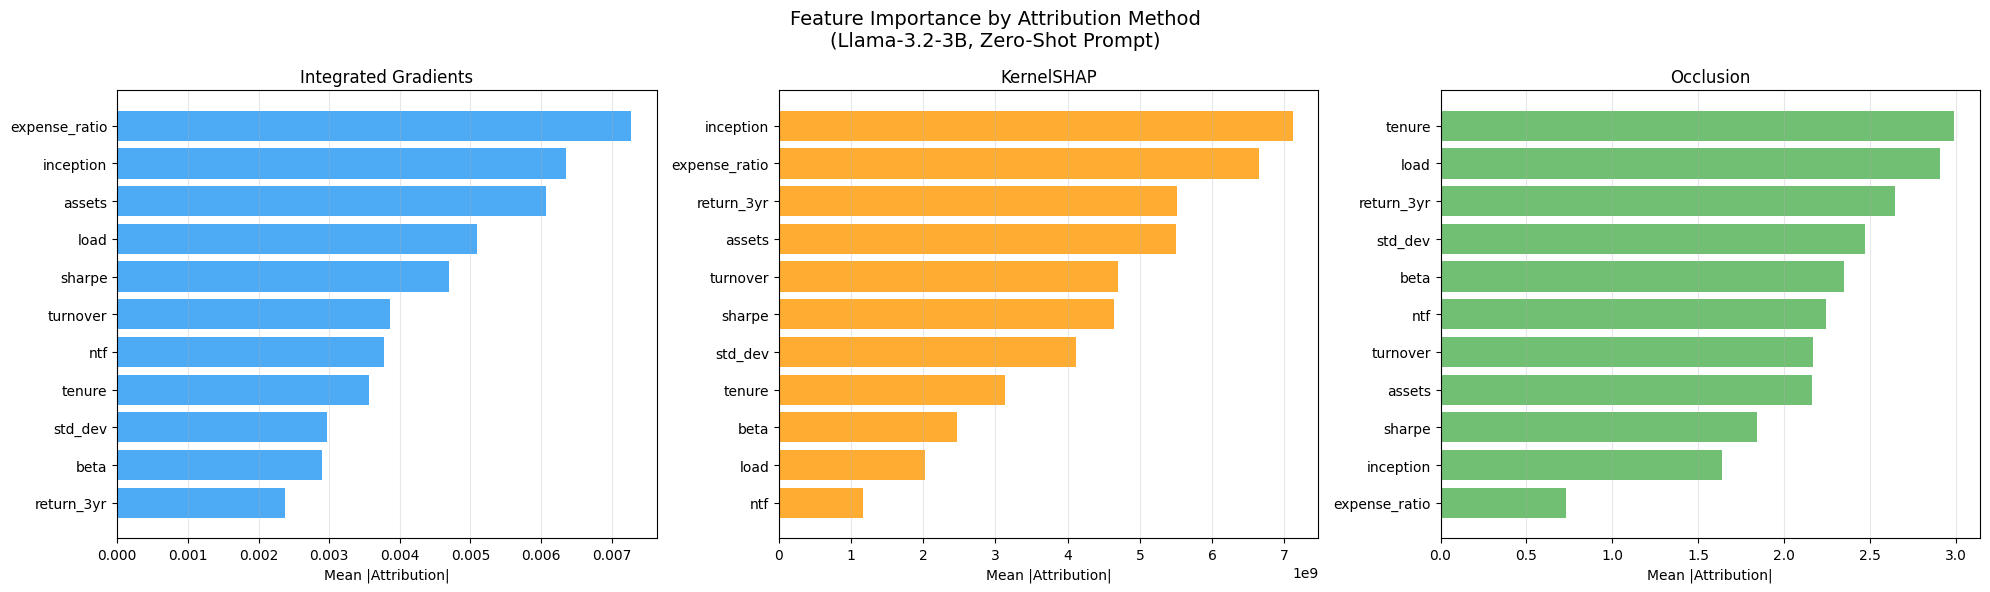

Saved plot to /content/RA-Mutual-Fund-Task/llm_eval_mutual_funds/interpreto_attributions/results/feature_importance_comparison.png


In [25]:
# Grouped bar chart comparing methods
if not all_importance.empty:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)

    methods = ["Integrated Gradients", "KernelSHAP", "Occlusion"]
    colors = ["#2196F3", "#FF9800", "#4CAF50"]

    for ax, method, color in zip(axes, methods, colors):
        method_data = all_importance[all_importance["method"] == method].sort_values("mean_total", ascending=True)
        if method_data.empty:
            ax.set_title(f"{method} (no data)")
            continue

        ax.barh(method_data["feature"], method_data["mean_total"], color=color, alpha=0.8)
        ax.set_xlabel("Mean |Attribution|")
        ax.set_title(method)
        ax.grid(axis="x", alpha=0.3)

    plt.suptitle("Feature Importance by Attribution Method\n(Llama-3.2-3B, Zero-Shot Prompt)", fontsize=14)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "feature_importance_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved plot to {OUTPUT_DIR / 'feature_importance_comparison.png'}")

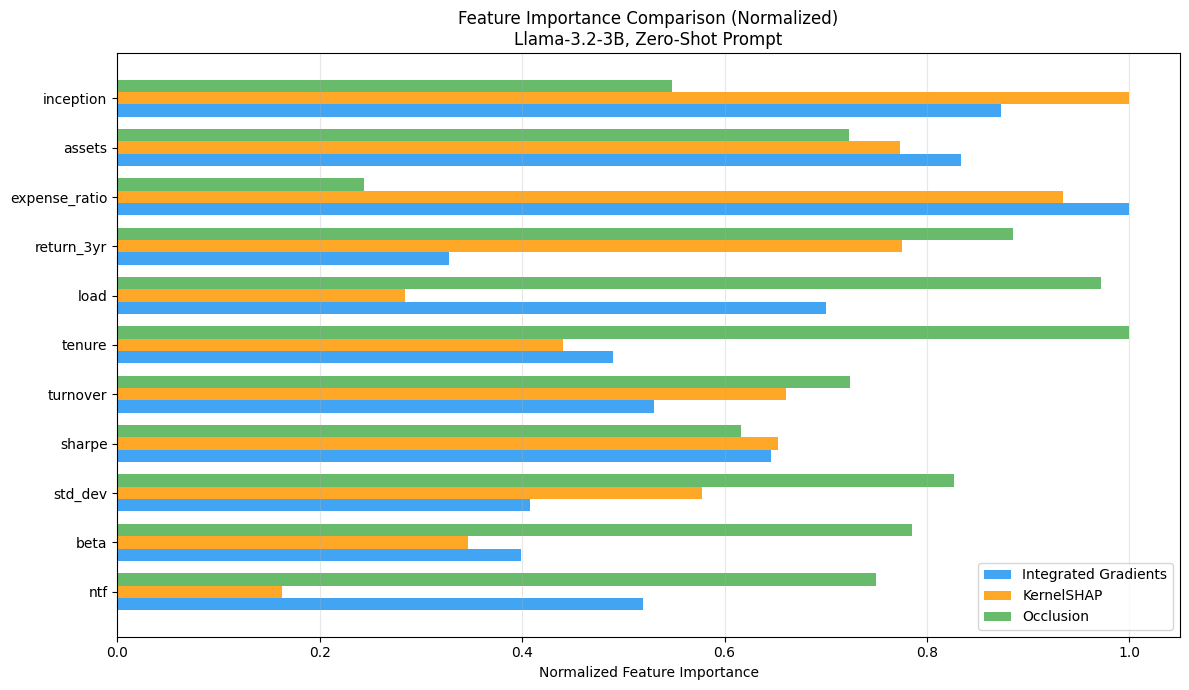

Saved to /content/RA-Mutual-Fund-Task/llm_eval_mutual_funds/interpreto_attributions/results/feature_importance_normalized.png


In [26]:
# Normalized comparison on a single plot
if not all_importance.empty:
    fig, ax = plt.subplots(figsize=(12, 7))

    methods = ["Integrated Gradients", "KernelSHAP", "Occlusion"]
    colors = ["#2196F3", "#FF9800", "#4CAF50"]
    width = 0.25

    # Get consistent feature ordering (by average rank across methods)
    if "normalized" in all_importance.columns:
        avg_norm = all_importance.groupby("feature")["normalized"].mean().sort_values(ascending=True)
        feature_order = avg_norm.index.tolist()
    else:
        feature_order = FEATURE_SHORT_NAMES

    y_pos = np.arange(len(feature_order))

    for j, (method, color) in enumerate(zip(methods, colors)):
        method_data = all_importance[all_importance["method"] == method]
        if method_data.empty:
            continue
        vals = []
        for feat in feature_order:
            row = method_data[method_data["feature"] == feat]
            vals.append(row["normalized"].values[0] if len(row) > 0 and "normalized" in row.columns else 0)
        ax.barh(y_pos + j * width, vals, width, label=method, color=color, alpha=0.85)

    ax.set_yticks(y_pos + width)
    ax.set_yticklabels(feature_order)
    ax.set_xlabel("Normalized Feature Importance")
    ax.set_title("Feature Importance Comparison (Normalized)\nLlama-3.2-3B, Zero-Shot Prompt")
    ax.legend(loc="lower right")
    ax.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "feature_importance_normalized.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved to {OUTPUT_DIR / 'feature_importance_normalized.png'}")

## 9. Per-Sample Feature Importance Heatmap

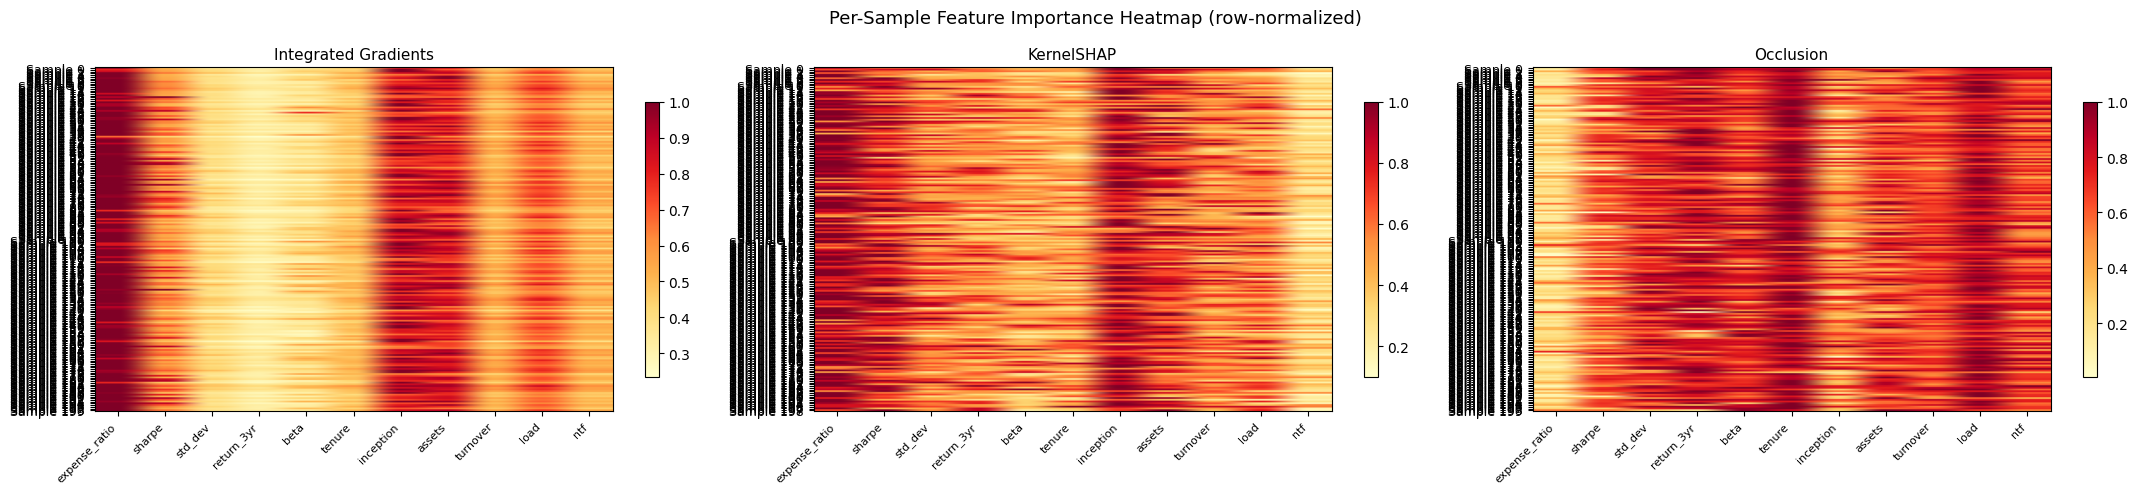

Saved to /content/RA-Mutual-Fund-Task/llm_eval_mutual_funds/interpreto_attributions/results/feature_importance_heatmap.png


In [27]:
def build_heatmap_data(results_list, method_name):
    """Build a samples x features matrix of importance scores."""
    if not results_list:
        return None
    matrix = []
    for r in results_list:
        row = [r["feature_scores"][feat]["total"] for feat in FEATURE_SHORT_NAMES]
        matrix.append(row)
    return np.array(matrix)


fig, axes = plt.subplots(1, 3, figsize=(22, 5))
method_names = ["Integrated Gradients", "KernelSHAP", "Occlusion"]
results_lists = [ig_results, shap_results, occ_results]

for ax, method_name, results_list in zip(axes, method_names, results_lists):
    matrix = build_heatmap_data(results_list, method_name)
    if matrix is not None and matrix.size > 0:
        # Normalize per-sample
        row_maxes = matrix.max(axis=1, keepdims=True)
        row_maxes[row_maxes == 0] = 1
        matrix_norm = matrix / row_maxes

        im = ax.imshow(matrix_norm, aspect="auto", cmap="YlOrRd")
        ax.set_xticks(range(len(FEATURE_SHORT_NAMES)))
        ax.set_xticklabels(FEATURE_SHORT_NAMES, rotation=45, ha="right", fontsize=8)
        ax.set_yticks(range(matrix.shape[0]))
        ax.set_yticklabels([f"Sample {i}" for i in range(matrix.shape[0])], fontsize=9)
        ax.set_title(method_name, fontsize=11)
        plt.colorbar(im, ax=ax, shrink=0.8)
    else:
        ax.set_title(f"{method_name} (no data)")

plt.suptitle("Per-Sample Feature Importance Heatmap (row-normalized)", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "feature_importance_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {OUTPUT_DIR / 'feature_importance_heatmap.png'}")

## 10. Cross-Method Rank Correlation

In [28]:
from scipy.stats import spearmanr, kendalltau

if not all_importance.empty:
    rank_pivot = all_importance.pivot(index="feature", columns="method", values="rank")

    methods_present = [m for m in ["Integrated Gradients", "KernelSHAP", "Occlusion"] if m in rank_pivot.columns]

    print("Spearman Rank Correlation between methods:\n")
    for i, m1 in enumerate(methods_present):
        for m2 in methods_present[i+1:]:
            rho, p = spearmanr(rank_pivot[m1], rank_pivot[m2])
            tau, p_tau = kendalltau(rank_pivot[m1], rank_pivot[m2])
            print(f"  {m1} vs {m2}:")
            print(f"    Spearman rho = {rho:.3f} (p = {p:.4f})")
            print(f"    Kendall tau  = {tau:.3f} (p = {p_tau:.4f})")
else:
    print("No results to compare.")

Spearman Rank Correlation between methods:

  Integrated Gradients vs KernelSHAP:
    Spearman rho = 0.427 (p = 0.1899)
    Kendall tau  = 0.309 (p = 0.2183)
  Integrated Gradients vs Occlusion:
    Spearman rho = -0.700 (p = 0.0165)
    Kendall tau  = -0.600 (p = 0.0099)
  KernelSHAP vs Occlusion:
    Spearman rho = -0.609 (p = 0.0467)
    Kendall tau  = -0.418 (p = 0.0866)


## 11. Connection to Linear Probing Results

Compare attribution-based feature importance with the linear probing accuracy from the earlier experiments. Features that the model encodes well (high probe accuracy) should also receive high attribution importance if the model actually uses them for decisions.

Correlation between probe accuracy and attribution importance:
  Spearman rho = 0.282 (p = 0.4011)

Detailed comparison:
               feature  test_accuracy  avg_attribution_importance
expense_ratio_f1_lower       0.975000                    0.726208
      sharpe_f1_higher       0.914000                    0.638257
        stdev_f1_lower       0.858000                    0.604253
  return_3yr_f1_higher       0.907000                    0.662550
         beta_f1_lower       0.853958                    0.510303
      tenure_f1_longer       0.921000                    0.643131
    inception_f1_older       0.946000                    0.807311
      assets_f1_higher       0.920000                    0.776674
     turnover_f1_lower       0.875000                    0.638313
            load_f1_no       0.991000                    0.652027
            ntf_f1_yes       0.996000                    0.477433


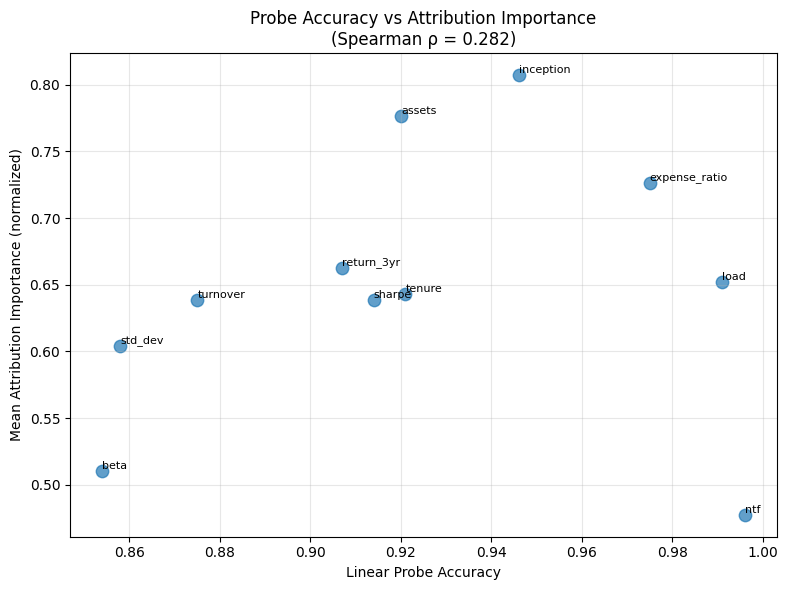

In [29]:
# Load linear probing results
probe_path = PROJECT_ROOT / "data" / "probe_results" / "probe_best_layers_llama-3.2-3b_2_fewshot_cot_temp0.csv"

if probe_path.exists():
    probe_df = pd.read_csv(probe_path)

    # Map probe feature names to our short names
    probe_feature_map = {
        "expense_ratio_f1_lower": "expense_ratio",
        "sharpe_f1_higher": "sharpe",
        "stdev_f1_lower": "std_dev",
        "return_3yr_f1_higher": "return_3yr",
        "beta_f1_lower": "beta",
        "tenure_f1_longer": "tenure",
        "inception_f1_older": "inception",
        "assets_f1_higher": "assets",
        "turnover_f1_lower": "turnover",
        "load_f1_no": "load",
        "ntf_f1_yes": "ntf",
        "medalist_f1_higher": "medalist",
    }

    probe_df["feature_short"] = probe_df["feature"].map(probe_feature_map)

    if not all_importance.empty:
        # Merge with attribution importance
        avg_importance = all_importance.groupby("feature")["normalized"].mean().reset_index()
        avg_importance.columns = ["feature_short", "avg_attribution_importance"]

        comparison = probe_df.merge(avg_importance, on="feature_short", how="left")
        comparison = comparison.dropna(subset=["avg_attribution_importance"])

        if len(comparison) > 2:
            rho, p = spearmanr(comparison["test_accuracy"], comparison["avg_attribution_importance"])
            print(f"Correlation between probe accuracy and attribution importance:")
            print(f"  Spearman rho = {rho:.3f} (p = {p:.4f})")
            print(f"\nDetailed comparison:")
            print(comparison[["feature", "test_accuracy", "avg_attribution_importance"]].to_string(index=False))

            # Scatter plot
            fig, ax = plt.subplots(figsize=(8, 6))
            ax.scatter(comparison["test_accuracy"], comparison["avg_attribution_importance"], s=80, alpha=0.7)
            for _, row in comparison.iterrows():
                ax.annotate(row["feature_short"],
                           (row["test_accuracy"], row["avg_attribution_importance"]),
                           fontsize=8, ha="left", va="bottom")
            ax.set_xlabel("Linear Probe Accuracy")
            ax.set_ylabel("Mean Attribution Importance (normalized)")
            ax.set_title(f"Probe Accuracy vs Attribution Importance\n(Spearman ρ = {rho:.3f})")
            ax.grid(alpha=0.3)
            plt.tight_layout()
            plt.savefig(OUTPUT_DIR / "probe_vs_attribution.png", dpi=150, bbox_inches="tight")
            plt.show()
        else:
            print("Not enough overlapping features for correlation analysis.")
else:
    print(f"Probe results not found at {probe_path}")

## 12. Fund 1 vs Fund 2 Attribution Comparison

For each feature, compare how much attribution is assigned to the fund 1 values versus fund 2 values. This helps understand whether the model focuses more on specific features of the "winning" or "losing" fund.

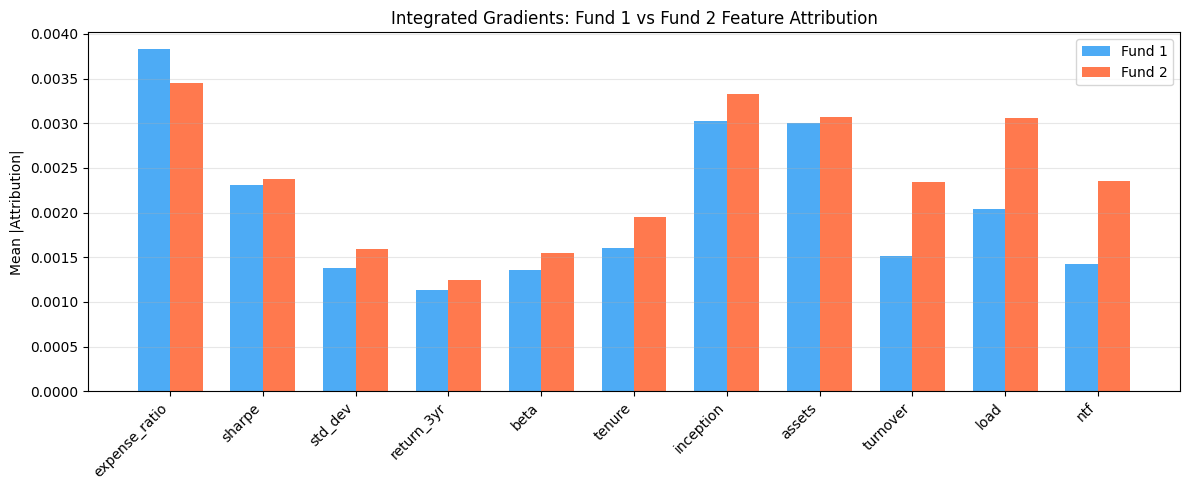

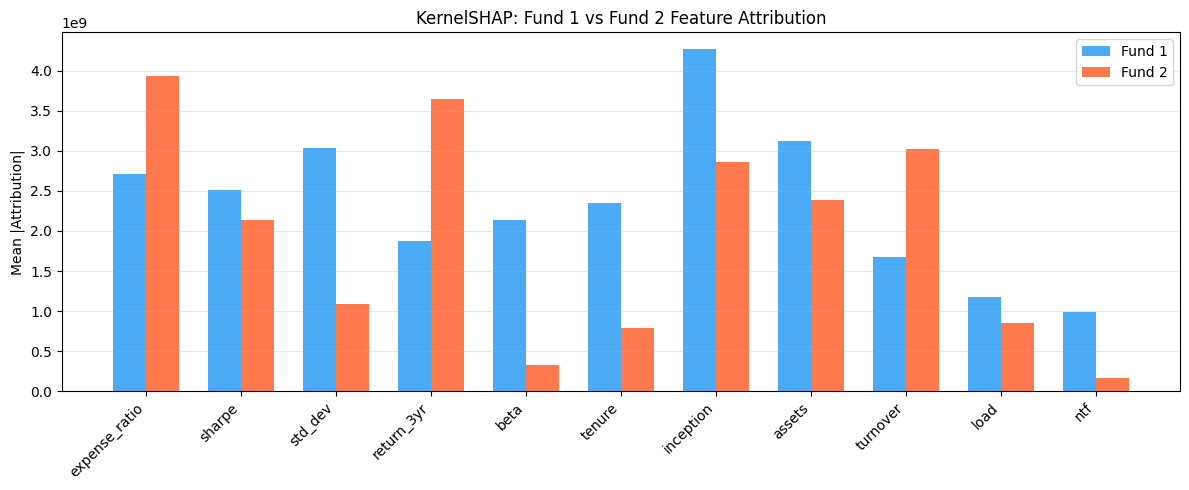

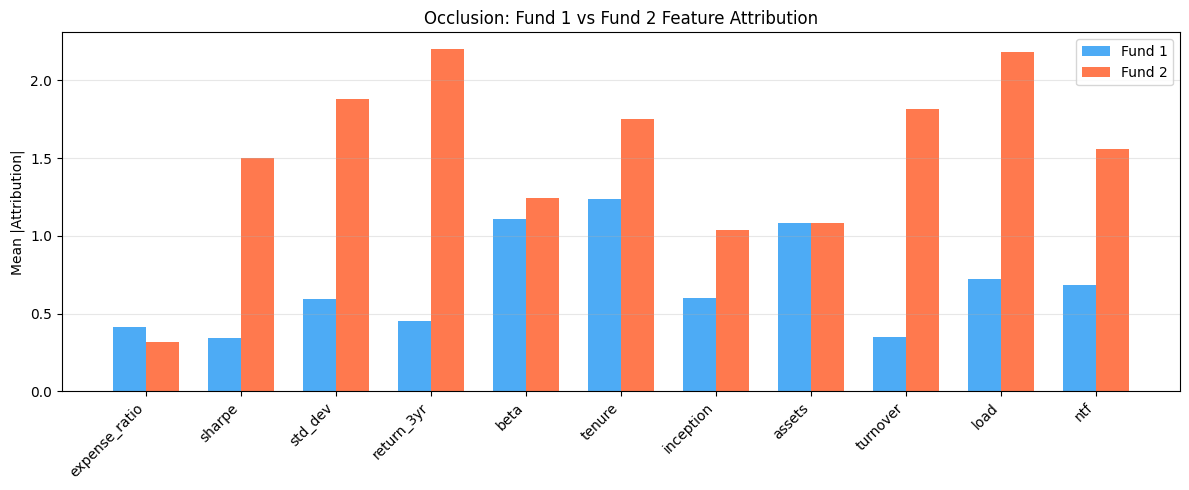

In [30]:
def plot_fund1_vs_fund2(results_list, method_name, output_dir):
    """Bar chart showing fund1 vs fund2 attribution per feature."""
    if not results_list:
        print(f"No results for {method_name}")
        return

    fund1_means = []
    fund2_means = []
    for feat in FEATURE_SHORT_NAMES:
        f1 = np.mean([r["feature_scores"][feat]["fund1"] for r in results_list])
        f2 = np.mean([r["feature_scores"][feat]["fund2"] for r in results_list])
        fund1_means.append(f1)
        fund2_means.append(f2)

    x = np.arange(len(FEATURE_SHORT_NAMES))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - width/2, fund1_means, width, label="Fund 1", color="#2196F3", alpha=0.8)
    ax.bar(x + width/2, fund2_means, width, label="Fund 2", color="#FF5722", alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(FEATURE_SHORT_NAMES, rotation=45, ha="right")
    ax.set_ylabel("Mean |Attribution|")
    ax.set_title(f"{method_name}: Fund 1 vs Fund 2 Feature Attribution")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / f"fund1_vs_fund2_{method_name.lower().replace(' ', '_')}.png",
                dpi=150, bbox_inches="tight")
    plt.show()


for method_name, results in [("Integrated Gradients", ig_results),
                              ("KernelSHAP", shap_results),
                              ("Occlusion", occ_results)]:
    plot_fund1_vs_fund2(results, method_name, OUTPUT_DIR)

## 13. Summary & Observations

In [31]:
print("=" * 70)
print("ATTRIBUTION ANALYSIS SUMMARY")
print("=" * 70)
print(f"\nModel: Llama-3.2-3B-Instruct")
print(f"Prompt: Zero-shot template")
print(f"Samples analyzed: {len(df_sample)} (max requested: {N_SAMPLES})")
print(f"\nMethods run:")
print(f"  - Integrated Gradients: {len(ig_results)} samples")
print(f"  - KernelSHAP: {len(shap_results)} samples")
print(f"  - Occlusion: {len(occ_results)} samples")

if not all_importance.empty:
    print(f"\nConsensus Feature Ranking (avg rank across methods):")
    consensus = all_importance.groupby("feature")["rank"].mean().sort_values()
    for rank_pos, (feat, avg_rank) in enumerate(consensus.items(), 1):
        print(f"  {rank_pos}. {feat} (avg rank: {avg_rank:.1f})")

print(f"\nOutputs saved to: {OUTPUT_DIR}")
print("  - feature_importance_all_methods.csv")
print("  - feature_importance_comparison.png")
print("  - feature_importance_normalized.png")
print("  - feature_importance_heatmap.png")
print("  - probe_vs_attribution.png")
print("  - fund1_vs_fund2_*.png")

ATTRIBUTION ANALYSIS SUMMARY

Model: Llama-3.2-3B-Instruct
Prompt: Zero-shot template
Samples analyzed: 200 (max requested: 200)

Methods run:
  - Integrated Gradients: 200 samples
  - KernelSHAP: 199 samples
  - Occlusion: 200 samples

Consensus Feature Ranking (avg rank across methods):
  1. inception (avg rank: 4.3)
  2. expense_ratio (avg rank: 4.7)
  3. assets (avg rank: 5.0)
  4. load (avg rank: 5.3)
  5. return_3yr (avg rank: 5.7)
  6. tenure (avg rank: 5.7)
  7. turnover (avg rank: 6.0)
  8. sharpe (avg rank: 6.7)
  9. std_dev (avg rank: 6.7)
  10. beta (avg rank: 8.0)
  11. ntf (avg rank: 8.0)

Outputs saved to: /content/RA-Mutual-Fund-Task/llm_eval_mutual_funds/interpreto_attributions/results
  - feature_importance_all_methods.csv
  - feature_importance_comparison.png
  - feature_importance_normalized.png
  - feature_importance_heatmap.png
  - probe_vs_attribution.png
  - fund1_vs_fund2_*.png


In [32]:
# Clean up GPU memory
import gc
del model
del ig_explainer, shap_explainer, occ_explainer
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"GPU memory after cleanup: {torch.cuda.memory_allocated(0)/1e9:.2f} GB")
print("Done.")

NameError: name 'ig_explainer' is not defined